In [ ]:
#Library

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
from sklearn.model_selection import ParameterGrid
from statsmodels.tsa.holtwinters import ExponentialSmoothing



In [4]:
# Get Bitcoin data
btc = yf.Ticker("BTC-USD")

btc_price = btc.history(period="max")

# S'assurer que la colonne Date est bien l'index
btc_price.index.name = "Date"
btc_price.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,0.0,0.0
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,0.0,0.0
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,0.0,0.0
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,0.0,0.0
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,0.0,0.0


In [7]:
btc_close = btc_price['Close']
btc_close.head()

Date
2014-09-17 00:00:00+00:00    457.334015
2014-09-18 00:00:00+00:00    424.440002
2014-09-19 00:00:00+00:00    394.795990
2014-09-20 00:00:00+00:00    408.903992
2014-09-21 00:00:00+00:00    398.821014
Name: Close, dtype: float64

In [8]:
#Index on daily data 
btc_price = btc_price.asfreq('D')
btc_price.index

DatetimeIndex(['2014-09-17 00:00:00+00:00', '2014-09-18 00:00:00+00:00',
               '2014-09-19 00:00:00+00:00', '2014-09-20 00:00:00+00:00',
               '2014-09-21 00:00:00+00:00', '2014-09-22 00:00:00+00:00',
               '2014-09-23 00:00:00+00:00', '2014-09-24 00:00:00+00:00',
               '2014-09-25 00:00:00+00:00', '2014-09-26 00:00:00+00:00',
               ...
               '2025-02-13 00:00:00+00:00', '2025-02-14 00:00:00+00:00',
               '2025-02-15 00:00:00+00:00', '2025-02-16 00:00:00+00:00',
               '2025-02-17 00:00:00+00:00', '2025-02-18 00:00:00+00:00',
               '2025-02-19 00:00:00+00:00', '2025-02-20 00:00:00+00:00',
               '2025-02-21 00:00:00+00:00', '2025-02-22 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='Date', length=3812, freq='D')

# Train Test

In [10]:
# Training and Test Split
periods = 7
train, test = btc_price.iloc[:-periods,0], btc_price.iloc[-periods:,0]

In [11]:
train

Date
2014-09-17 00:00:00+00:00      465.864014
2014-09-18 00:00:00+00:00      456.859985
2014-09-19 00:00:00+00:00      424.102997
2014-09-20 00:00:00+00:00      394.673004
2014-09-21 00:00:00+00:00      408.084991
                                 ...     
2025-02-11 00:00:00+00:00    97438.132812
2025-02-12 00:00:00+00:00    95745.695312
2025-02-13 00:00:00+00:00    97888.750000
2025-02-14 00:00:00+00:00    96623.367188
2025-02-15 00:00:00+00:00    97508.382812
Freq: D, Name: Open, Length: 3805, dtype: float64

In [12]:
test

Date
2025-02-16 00:00:00+00:00    97580.492188
2025-02-17 00:00:00+00:00    96179.007812
2025-02-18 00:00:00+00:00    95773.812500
2025-02-19 00:00:00+00:00    95532.531250
2025-02-20 00:00:00+00:00    96632.679688
2025-02-21 00:00:00+00:00    98340.671875
2025-02-22 00:00:00+00:00    96117.070312
Freq: D, Name: Open, dtype: float64

In [18]:
# Triple Exponential Smoothing Model and Predictions
model_triple = ExponentialSmoothing(train, trend = "add", seasonal='mul', seasonal_periods=52).fit()
prediction_triple = model_triple.forecast(len(test))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


# Model Assessment

In [20]:
# Function to assess model and visualize output 
def model_assessment(train, test, predictions, chart_title):
    # Plot training, test, and forecasts
    plt.figure(figsize=(10,5))
    plt.plot(train, label = 'Train')
    plt.plot(test,  label = 'Test')
    plt.plot(predictions,  label = 'Forecast')
    plt.title(f'Train, Test and Predictions with {chart_title}')
    plt.legend()
    plt.show()

    # Calculating the MAE, RMSE, and MAPE
    mae = mean_absolute_error(test, predictions)
    rmse = mean_squared_error(test, predictions, squared=False)
    mape = mean_absolute_percentage_error(test, predictions)
    print(f"mae = {mae:.2f}")
    print(f"rmse = {rmse:.2f}")
    print(f"mape = {mape *100:.2f}%")

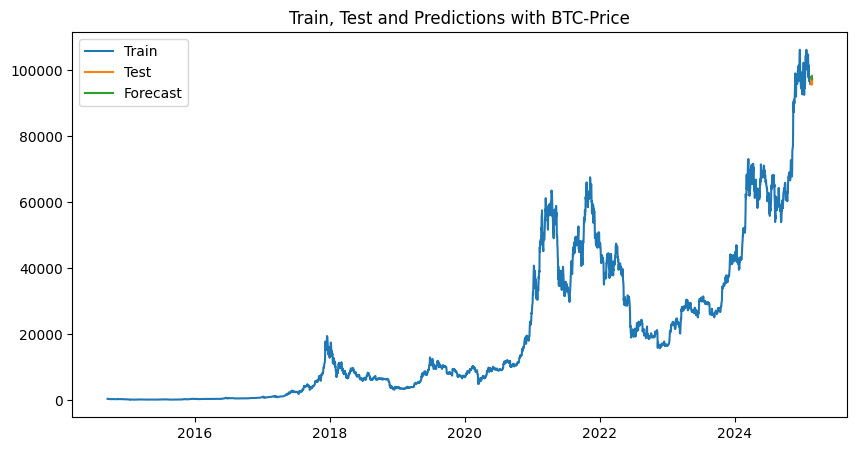

mae = 1374.98
rmse = 1580.31
mape = 1.43%


In [21]:
btc_test = model_assessment(train, test, prediction_triple, 'BTC-Price')

In [22]:
prediction_triple

2025-02-16 00:00:00+00:00    97734.204494
2025-02-17 00:00:00+00:00    97874.712879
2025-02-18 00:00:00+00:00    97939.565316
2025-02-19 00:00:00+00:00    98028.877679
2025-02-20 00:00:00+00:00    98102.179589
2025-02-21 00:00:00+00:00    97792.503447
2025-02-22 00:00:00+00:00    97212.711347
Freq: D, dtype: float64